### Final Project
Course: ADSP 31006 ON02 Time Series Analysis and Forecasting

Students: Maja Ivanovic, Victoria Li, Kathleen Nie, Mpiira Tabuti

### 0. Dependencies, data import, and helper functions

In [2]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt

import joblib
from pathlib import Path

from dtaidistance import dtw

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    balanced_accuracy_score,
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
DATA_DIR     = Path("../ECG200")
MODELS_DIR   = Path("../models")
RANDOM_STATE = 42

In [7]:
def dtw_distance(u, v):
    return dtw.distance(u, v)

# A. Normal un-transformed data

### A.1. Pre-processing

In [10]:
# --- Load TRAIN ---
df_train = pd.read_csv(
    DATA_DIR / "ECG200_TRAIN.txt",
    sep='\s+',
    header=None
)

# --- Load TEST ---
df_test = pd.read_csv(
    DATA_DIR / "ECG200_TEST.txt",
    sep='\s+',
    header=None
)

# --- Split into features and labels ---
y_train = df_train.iloc[:, 0].values
X_train = df_train.iloc[:, 1:].values

y_test  = df_test.iloc[:, 0].values
X_test  = df_test.iloc[:, 1:].values

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9438/2814001526.py:4: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_9438/2814001526.py:11: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


### A.3. Load and apply models

In [11]:
model_files = {
    "knn_dtw_k5": MODELS_DIR / "knn_dtw_k5.pkl",
    "knn_euclidean_k5": MODELS_DIR / "knn_euclidean_k5.pkl",
    "logreg": MODELS_DIR / "logreg.pkl",
    "svm_rbf": MODELS_DIR / "svm_rbf.pkl",
}

rows = []

for name, path in model_files.items():

    model = joblib.load(path)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[-1, 1]).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    rows.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall (Sensitivity)": recall,
        "Specificity": specificity,
        "F1": f1,
        "Balanced_Accuracy": bal_acc,
        "AUC": auc,
    })

results_df = pd.DataFrame(rows).sort_values(by="F1", ascending=False)

print("\n=== Model Evaluation Summary (Test Set) ===")
print(results_df.to_string(index=False))


=== Model Evaluation Summary (Test Set) ===
           Model  Accuracy  Precision  Recall (Sensitivity)  Specificity       F1  Balanced_Accuracy      AUC
knn_euclidean_k5      0.90   0.897059              0.953125     0.805556 0.924242           0.879340 0.953776
         svm_rbf      0.87   0.880597              0.921875     0.777778 0.900763           0.849826 0.931424
          logreg      0.84   0.900000              0.843750     0.833333 0.870968           0.838542 0.910156
      knn_dtw_k5      0.79   0.802817              0.890625     0.611111 0.844444           0.750868 0.916667


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using

# B. Phase shifted data

### B.1. Pre-processing

Train jitter — min: -19  max: +20  mean: +1.07
Test  jitter — min: -20  max: +20  mean: -0.37


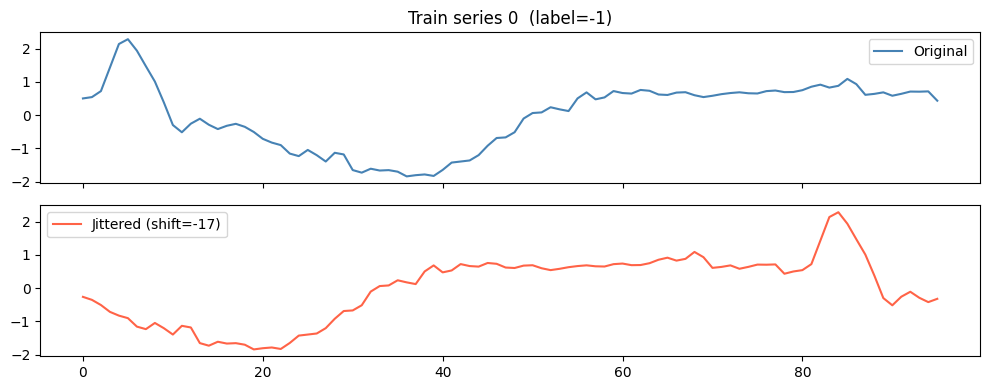

In [ ]:
RNG = np.random.default_rng(seed=RANDOM_STATE)   

def jitter_series(X, max_shift=20):
    """Return a copy of X where every row is circularly shifted by a
    random integer in [-max_shift, max_shift]."""
    shifts = RNG.integers(-max_shift, max_shift + 1, size=len(X))
    return np.array([np.roll(row, s) for row, s in zip(X, shifts)]), shifts

X_train_jit, shifts_train = jitter_series(X_train)
X_test_jit,  shifts_test  = jitter_series(X_test)

print(f"Train jitter — min: {shifts_train.min():+d}  max: {shifts_train.max():+d}  "
        f"mean: {shifts_train.mean():+.2f}")
print(f"Test  jitter — min: {shifts_test.min():+d}  max: {shifts_test.max():+d}  "
        f"mean: {shifts_test.mean():+.2f}")

# --- Sanity check: one original time series vs. its jittered version ---
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
idx = 0
axes[0].plot(X_train[idx], label="Original", color="steelblue")
axes[0].set_title(f"Train series {idx}  (label={y_train[idx]:.0f})")
axes[0].legend()
axes[1].plot(X_train_jit[idx], label=f"Jittered (shift={shifts_train[idx]:+d})", color="tomato")
axes[1].legend()
plt.tight_layout()
plt.show()


### B.2. Build and save classification models

In [ ]:
#Continue to use models from A.2.

Jittered models trained and saved.


### B.3. Load and apply models

In [16]:
model_files = {
    "knn_dtw_k5":       MODELS_DIR / "knn_dtw_k5.pkl",
    "knn_euclidean_k5": MODELS_DIR / "knn_euclidean_k5.pkl",
    "logreg":           MODELS_DIR / "logreg.pkl",
    "svm_rbf":          MODELS_DIR / "svm_rbf.pkl",
}

rows_jit = []

for name, path in model_files.items():

    model = joblib.load(path)

    y_pred = model.predict(X_test_jit)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_jit)[:, 1]
    else:
        y_prob = None

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[-1, 1]).ravel()

    rows_jit.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, y_pred),
        "Precision":            precision_score(y_test, y_pred, pos_label=1),
        "Recall (Sensitivity)": recall_score(y_test, y_pred, pos_label=1),
        "Specificity":          tn / (tn + fp),
        "F1":                   f1_score(y_test, y_pred, pos_label=1),
        "Balanced_Accuracy":    balanced_accuracy_score(y_test, y_pred),
        "AUC":                  roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
    })

results_jit_df = pd.DataFrame(rows_jit).sort_values("F1", ascending=False)

print("\n=== Jittered Test Set (trained on clean) ===")
print(results_jit_df.to_string(index=False))

# --- Degradation vs. original clean results ---
degradation = (
    results_df[["Model", "F1"]]
    .rename(columns={"F1": "F1_clean"})
    .merge(results_jit_df[["Model", "F1"]], on="Model")
    .assign(F1_drop=lambda d: d["F1_clean"] - d["F1"])
    .sort_values("F1_drop", ascending=False)
)

print("\n=== F1 degradation from jitter ===")
print(degradation.to_string(index=False))



=== Jittered Test Set (trained on clean) ===
           Model  Accuracy  Precision  Recall (Sensitivity)  Specificity       F1  Balanced_Accuracy      AUC
      knn_dtw_k5      0.70   0.729730              0.843750     0.444444 0.782609           0.644097 0.720703
          logreg      0.60   0.785714              0.515625     0.750000 0.622642           0.632812 0.638889
knn_euclidean_k5      0.48   0.620000              0.484375     0.472222 0.543860           0.478299 0.482205
         svm_rbf      0.56   0.833333              0.390625     0.861111 0.531915           0.625868 0.660590

=== F1 degradation from jitter ===
           Model  F1_clean       F1  F1_drop
knn_euclidean_k5  0.924242 0.543860 0.380383
         svm_rbf  0.900763 0.531915 0.368848
          logreg  0.870968 0.622642 0.248326
      knn_dtw_k5  0.844444 0.782609 0.061836
